* 구글 드라이브 연결

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


* 필요한 라이브러리 설치

In [2]:
!pip install -q langchain-openai langchain-community streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 77.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 102.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 89.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.1 which is incompatible.


* 라이브러리 로딩

In [3]:
# 기본 제공 라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import json
import os
import openai
import ast
import re

from typing import TypedDict, Annotated, List, Optional, Literal, Dict, Any
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langgraph.graph import END, START, StateGraph, MessagesState
from langchain_openai import ChatOpenAI

# 더 필요한 라이브러리가 있다면 추가합시다. -----




/usr/local/lib/python3.12/dist-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


### (3) OpenAI API Key 확인

In [10]:
def load_api_keys(filepath="api_key.txt"):
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line and "=" in line:
                key, value = line.split("=", 1)
                os.environ[key.strip()] = value.strip()

path = '/content/drive/MyDrive/proj2_agent/'

# API 키 로드 및 환경변수 설정
load_api_keys(path + 'api_key.txt')

In [ ]:
print(os.environ['OPENAI_API_KEY'][:30])

* 운영환경 설정

In [ ]:
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "proj2_agent"
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"

#### **1) State & LLM 준비**

In [ ]:
class ReviewState(TypedDict):
    messages: Annotated[list, add_messages]
    input_review: str
    score: int
    aspect_list: List[str]
    criti_score: str
    result: dict

    feedback: str

    next_step: Optional[Literal["analyzer", "critic", "end"]]
    max_num: int
    current_num: int

    current_agent: Optional[str]

* llm 준비

In [ ]:
visor_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.2)
analyzer_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.2)
criti_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.2)

* Analyzer Agent

In [ ]:
state: ReviewState = {
    "input_review": '보습력이 정말 좋아요. 향도 괜찮지만 가격은 조금 비싸요.',
    "score": 3,
    "result": "",
    "aspect_list": ['보습', '가격', '향', '포장']
}

In [ ]:
def analyzer_node(state: ReviewState):
  review = state.get("input_review") or []
  result = state.get("result") or []
  aspect_list = state.get("aspect_list") or []
  score = state.get("score") or 0
  feedback = state.get("criti_score") or "없음 (최초 분석)"

  sys = """
너는 리뷰 분석 전문가야. 다음 지침에 따라 입력받은 사용자의 리뷰를 분석해줘.
만약 [수정 요청 피드백]이 제공된다면, 이전의 실수를 교정하여 결과를 다시 작성해야 해.

[지침]
1. 제시된 [후보 속성] 중에서 리뷰에 언급된 것만 추출해.
2. **중요: 'aspect' 리스트에 담긴 속성의 순서는 반드시 [후보 속성]에 나열된 순서를 유지해야 해.**
3. 각 속성에 대한 만족도를 판별해 (만족/긍정은 1, 불만족/부정은 0).
4. 'label' 리스트의 값은 'aspect' 리스트의 순서와 1:1로 정확히 매칭되어야 해.
5. 리뷰에 명시된 별점(score)을 추출해.
6. 결과는 반드시 아래의 JSON 형식으로만 출력하고, 다른 설명은 하지마.

[출력 형식]
{
  "review": "리뷰 원문",
  "aspect": ["추출된 속성 리스트"],
  "label": [각 속성에 대응하는 1 또는 0 리스트],
  "score": 별점숫자
}
"""
  human = f"""
[리뷰 원문]
{review}

[후보 속성]
{aspect_list}

[별점 숫자]
{score}

[수정 요청 피드백]
{feedback}
"""

  resp = analyzer_llm.invoke([SystemMessage(content=sys),
                       HumanMessage(content=human)])
  data_dict = json.loads(resp.content)
  result = data_dict
  return {
      "messages": [AIMessage(content=f"[Analyzer Result]\n{resp.content}")],
      "result": result,
      "current_agent": "analyzer",
  }

In [ ]:
state = analyzer_node(state)

In [ ]:
state["result"]

* Critic Agent

In [ ]:
state: ReviewState = {
    "input_review": '보습력이 정말 좋아요. 향도 괜찮지만 가격은 조금 비싸요.',
    "score": 3,
    "result": {'id': 1,
   'review': '보습력이 정말 좋아요. 향도 괜찮지만 가격은 조금 비싸요.',
   'aspect': ['보습', '가격', '향'],
   'label': [1, 0, 1],
   'score': 3},
    "aspect_list": ['보습', '가격', '향', '포장']
}

In [ ]:
def critic_node(state: ReviewState):

  review = state.get("input_review") or ""
  aspect_list = state.get("aspect_list") or []
  result = state.get("result") or ""
  criti_score = state.get("criti_score") or ""
  current_num = state.get("current_num") or 0

  sys = """
너는 리뷰 분석 결과의 정확성을 검증하는 품질 관리(QA) 전문가야.
Analyzer가 추출한 결과가 리뷰 원문의 내용과 논리적으로 일치하는지 검토해줘.

#검토 지침
1. 일관성: 추출된 'aspect'가 리뷰 원문에 실제로 언급된 내용인지 확인해. (언급되지 않은 속성은 포함되지 않아야 함)
2. 정확성: 각 'aspect'에 매칭된 'label'(1: 만족, 0: 불만족)이 리뷰의 맥락과 맞는지 확인해.
3. 형식: 결과가 약속된 JSON 형식을 유지하고 있는지 확인해.
4. 순서: **[중요] 추출된 'aspect'들은 [후보 속성]에 나열된 상대적 순서를 유지해야 해.**
   - 리뷰에 언급되지 않아 제외된 속성이 있더라도, 남아있는 속성들 간의 앞뒤 순서가 [후보 속성] 리스트의 순서와 일치하면 OK야.
   - 예: 후보가 [A, B, C, D]이고 추출이 [A, C]라면 순서가 맞는 것으로 간주함.

#판단 기준
- 분석 결과에 논리적/형식적 오류가 없는지
- 리뷰에 언급되지 않은 속성이 포함되어 있지는 않은지
- **존재하는 속성들끼리의 순서가 후보 리스트의 우선순위와 일치하는지**

#출력
[FEEDBACK]
- ...
- ...
[VERDICT]
VERDICT: OK
또는
VERDICT: REVISE
"""

  human = f"""
[리뷰 원문]
{review}

[후보 속성]
{aspect_list}

[Analyzer의 분석 결과]
{result}
"""
  resp = criti_llm.invoke([SystemMessage(content=sys),
                       HumanMessage(content=human)])
  current_num = current_num + 1
  return {
        "messages": [AIMessage(content=f"[CRITIC RESULT]\n{resp.content}")],
        "criti_score": resp.content,
        "current_num" : current_num,
        "current_agent": "critic",
    }

In [ ]:
state = critic_node(state)

In [ ]:
state["criti_score"]

## 별점 1~2점인 요소들을 딕셔너리로 반환하는 함수

In [ ]:
# 별점 1~2점인 요소가 있다면 딕셔너리로 반환하는 함수
def select_low_score_reviews():
    conn = sqlite3.connect("user_review_db.db")
    cursor = conn.cursor()

    cursor.execute("""
        SELECT id, review, aspect, label, score, updated_at
        FROM user_reviews
        WHERE score IN (1, 2)
        ORDER BY score ASC, updated_at DESC
    """)
    rows = cursor.fetchall()
    conn.close()

    reviews = []
    for row in rows:
        id_, review, aspect, label, score, updated_at = row

        # aspect, label은 TEXT로 저장되어 있으므로 리스트로 변환
        # (분석 전이면 NULL일 수 있어서 안전하게 처리)
        try:
            aspect_parsed = ast.literal_eval(aspect) if aspect else None
        except (ValueError, SyntaxError):
            aspect_parsed = aspect  # 파싱 실패 시 원본 문자열 유지

        try:
            label_parsed = ast.literal_eval(label) if label else None
        except (ValueError, SyntaxError):
            label_parsed = label

        reviews.append({
            "review": review,
            "aspect": aspect_parsed,
            "label": label_parsed,
        })

    return {
        "total_count": len(reviews),
        "reviews": reviews,
    }

In [ ]:
tt = {
    "total_count": 0,
    "reviews": []
}

In [ ]:
tt = select_low_score_reviews()

In [ ]:
tt

{'total_count': 33,
 'reviews': [{'review': '홈쇼핑 광고에서도 정말 많이 하고 많은 분들이 궁금해하셨던 바로 그 제품 사용 후기 가져왔습니다. 저도 구매를 직접 해서 써 봤는데 좋은 점이 없는 것 같아서 알려드리고 싶었어요... 단점이 너무 많은 제품이라.. 무슨 말부터 시작을 해야 될 지 모르겠습니다. 일단 이 제품을 사게 된 계기는 홈쇼핑 광고를 보고 샀어요. 구성이 너무 좋아서 구매를 했습니다. 배송은 빨리 왔고 오자 마자 기대를 가지고 사용하게 되었어요. 하지만 하는 내내 풍기는 이상한 냄새에 머리가 아팠습니다. 두피에 자극도 있어서 지금 너무 가려운 것 같습니다...ㅠㅠ 약을 먹어도 가려움이 없어지지 않네요. 염색제 색상도 마음에 들지 않았고 발색도 너무 어둡게 나온 것 같습니다. 결론은 저는 추천하고 싶지 않은 제품이네요~ 다른 염색약 사용하시는 것이 더 좋을 것 같다는 게 제 결론입니다..!!',
   'aspect': ['보습', '가격', '향', '포장'],
   'label': [0, 1, 0, 0]},
  {'review': '괜히 처음부터 대량 구매한 것 같습니다. 제 피부에는 잘 안 맞는지 피부결이 탁하고 거친 느낌이네요. 주위에서 피부 관리해야겠다고 그래요. 꾸준히 믿고 사용하려고 많이 샀는데 후회 되네요.',
   'aspect': [],
   'label': []},
  {'review': '향수 필요해서 찾아 보다가 이 제품 할인 해서 구매하게 되었는데 품질이 생각보다 좋지는 않네요!! 저는 사용하고 좋지 않아서 후기 작성합니다... 유통기한도 엄청 짧은 제품을 받아서 기분이 안 좋고 용기가 너무 무거워 좋지 않네요.... 향은 기대보다 좋지 않아서 아쉬운 것 같습니다.. 잔향도 살짝 너무 별로에요... 괜히 산 것 같다는 생각이 듭니다!! 가성비 없는 것 같아요! 이거 뿌리고 동생한테 물어보니까 향이 별로라고 하는 걸 보면 저만 그렇게 느끼는 게 아닌 것 같습니다...!! 추천 하고 싶지 않

* Supervisor Agent

In [ ]:
def supervisor_node(state: ReviewState):
  print("-다음 경로 탐색중...-")

  if not state.get("result"):
    next_step = "analyzer"

  elif not state.get("current_num"):
    next_step = "critic"

  else:
    criti = state.get("criti_score") or ""

    if "VERDICT: OK" in criti:
      next_step = "end"

    elif "VERDICT: REVISE" in criti and state.get("current_num") < state.get("max_num"):
      print("-!재분석이 요구됩니다.!-")
      next_step = "analyzer"

    else:
      next_step = "end"

  print(f"-{next_step}으로 이동합니다.-")

  return {
      "next_step": next_step,
      "current_agent": "supervisor",
  }

* route_next 함수

In [ ]:
def route_next(state: ReviewState):
    return state["next_step"]

* 그래프

In [ ]:
builder = StateGraph(ReviewState)

builder.add_node("analyzer", analyzer_node)
builder.add_node("critic", critic_node)
builder.add_node("supervisor",supervisor_node)

builder.add_edge(START, "supervisor")

builder.add_conditional_edges("supervisor", route_next,
    { "analyzer": "analyzer",
        "critic": "critic", "end": END }
)

builder.add_edge("analyzer", "supervisor")
builder.add_edge("critic", "supervisor")

app = builder.compile()

In [ ]:
app

In [ ]:
# 테스트 입력 준비
test_input: ReviewState = {
    "messages":     [],
    "input_review": "보습력이 정말 좋아요. 향도 괜찮지만 가격은 조금 비싸요.",
    "score":        4,
    "aspect_list":  ["보습", "가격", "향", "포장"],
    "result":       {},
    "criti_score":  "",
    "current_num":  0,
    "max_num":      3,
    "next_step":    None,
}

# Agent 실행 (실행과 동시에 LangSmith로 trace 자동 전송)
result = app.invoke(test_input)

# 결과 확인
print("===== 최종 분석 결과 =====")
print(result["result"])
print("\n===== Critic 평가 =====")
print(result["criti_score"])
print(f"\n===== 반복 횟수: {result['current_num']} =====")

#### **1) State 보완**

In [4]:
ReasonCode = Literal["OUTPUT_ERROR", "SCOPE_ERROR", "EVIDENCE_ERROR", "QUALITY_ERROR", "OK"]

class ReviewState(TypedDict):
    messages: Annotated[list, add_messages]
    input_review: str
    max_num: int
    current_num: int
    score: int
    next_step: Optional[Literal["analyzer", "critic", "end"]]
    result: dict
    aspect_list: List[str]
    criti_score: str

    # 추가
    current_agent: Optional[str]

    reason_code: Optional[ReasonCode]
    repair_directive: str



In [ ]:
visor_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.2)
analyzer_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.2)
criti_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.2)

#### **2) Agent 노드 준비**

In [5]:
# 정책 및 필요 함수 준비 : 아래 내용을 수정해서 사용하세요.

REASON_CODES = {"OUTPUT_ERROR", "SCOPE_ERROR", "EVIDENCE_ERROR", "QUALITY_ERROR", "OK"}
RETRYABLE = {"OUTPUT_ERROR", "SCOPE_ERROR", "EVIDENCE_ERROR"}

REPAIR_TEMPLATES = {
    "OUTPUT_ERROR": "dict 1개만 출력. 코드블록/설명 없이 items 구조와 label(0/1)을 맞춰라.",
    "SCOPE_ERROR": "aspect는 보습, 가격, 향, 포장만 사용하라. 다른 표현은 가장 가까운 값으로 매핑하라.",
    "EVIDENCE_ERROR": "리뷰 원문에 실제 언급되지 않은 aspect는 제외하라.",
    "QUALITY_ERROR": "리뷰에 없는 내용을 만들지 말고, 애매하면 해당 aspect는 제외하라."
}

# 딕셔너리 파싱 함
def parse_dict(text, default):
    try:
        return ast.literal_eval(text)
    except:
        return default

* Analyzer Agents 보완

In [ ]:
aspect_list = ['가격', '구성', '제형 밀도', '향', '사용감', '지속력', '디자인', '만족도', '보습', '휴대성', '배송', '발림성', '용량', '사은품', '포장', '커버력', '피부표현', '세팅력', '발색', '소독효과', '흡수력', '유통기한', '유통 기한', '사이즈', '편의성', '품질', '색감', '제형', '피부타입', '유분감', '유효기간', '자외선 차단', '톤업', '진정', '크기', '피부결', '세정력', '번짐', '밀착력', '색상', '위생', '손상케어', '주름개선', '자극', '클렌징', '효과', '할인', '재구매', '성분', '피부']

In [ ]:
state: ReviewState = {
    "input_review": '보습력이 정말 좋아요. 향도 괜찮지만 가격은 조금 비싸요.',
    "score": 0,
    "result": "",
    "aspect_list": aspect_list
}

In [6]:
def analyzer_node(state: ReviewState):
    review = state.get("input_review") or "" # 리뷰 원문
    aspect = state.get("aspect_list") or []   # 후보 속성 리스트
    score = state.get("score") or 0   # 리뷰 별점
    directive = state.get("repair_directive") or ""
    retry_cnt = state.get("current_num") or 0
    feedback  = directive if directive else "없음 (최초 분석)"

    sys = """
너는 리뷰 분석 전문가야. 다음 지침에 따라 입력받은 사용자의 리뷰를 분석해줘.
만약 [수정 요청 피드백]이 제공된다면, 이전의 실수를 교정하여 결과를 다시 작성해야 해.

[지침]
1. 제시된 [후보 속성] 중에서 리뷰 내용과 일치하는 것을 추출해. **단, '성능', '효과'처럼 포괄적인 단어가 쓰였더라도 문맥상 화장품의 기능(예: 보습력)을 뜻한다면 유연하게 해석해서 해당 후보 속성으로 매칭해줘.**
'다 좋다', '전부 좋다' 등 전반적 긍정 표현은 모든 후보 속성에 대한 긍정으로 해석해.'성능', '효과'처럼 포괄적인 단어도 문맥상 화장품 기능을 뜻한다면 유연하게 매칭해줘.
2. aspect 리스트에 담긴 속성의 순서는 반드시 [후보 속성]에 나열된 순서를 유지해야 해.
3. 각 속성에 대한 만족도를 판별해. 만족/긍정은 1, 불만족/부정은 0이야.
4. label 리스트의 값은 aspect 리스트의 순서와 1:1로 정확히 매칭되어야 해.
5. [중요: 별점 산정]
- 입력된 [별점 숫자]가 0보다 크면 그 숫자를 그대로 사용해.
- 입력된 [별점 숫자]가 0이라면, 리뷰 원문의 뉘앙스를 분석하여 네가 직접 1~5점 사이의 별점을 책정해.
(매우 만족: 5, 만족: 4, 보통: 3, 불만족: 2, 매우 불만족: 1)
6. 결과는 반드시 아래 JSON 형식으로만 출력하고, 다른 설명은 하지마.

[출력 형식]
{
"review": "리뷰 원문",
"aspect": ["추출된 속성 리스트"],
"label": [각 속성에 대응하는 1 또는 0 리스트],
"score": 별점 산정 숫자
}
"""

    human = f"""
    [리뷰 원문]
    {review}

    [후보 속성]
    {aspect}

    [별점 숫자]
    {score}

    [수정 요청 피드백]  ← {retry_cnt}회차 재시도
    {feedback}
    """

    resp = analyzer_llm.invoke([
        SystemMessage(content=sys),
        HumanMessage(content=human)
    ])

    content = resp.content.strip()
    content = content.replace("```json", "").replace("```", "").strip()

    data_dict = json.loads(content)

    return {
        # 실행 로그 누적
        "messages": [AIMessage(content=f"[Analyzer Result]\n{resp.content}")],
        "next_step": "supervisor",
        "result": data_dict,        # Analyzer가 만든 분석 결과 JSON을 넣음
        "current_agent": "analyzer", # 현재 실행 중인 Agent (Trace 가독성용)
        "criti_score": " ",
        "reason_code": []
    }

In [ ]:
state = analyzer_node(state)

In [ ]:
state["result"]

* Critic Agent 보완

In [ ]:
state: ReviewState = {
    "input_review": '보습력이 정말 좋아요. 향도 괜찮지만 가격은 조금 비싸요.',
    "score": 0,
    "result": {'id': 1,
   'review': '보습력이 정말 좋아요. 향도 괜찮지만 가격은 조금 비싸요.',
   'aspect': ['가격', '향'],
   'label': [0, 1],
   'score': 3},
    "aspect_list": ['보습', '가격', '향', '포장']
}

In [7]:
def critic_node(state: ReviewState):
    input_review = state.get("input_review", "")
    result = state.get("result", {})
    aspect_list = state.get("aspect_list", [])
    reason_code = state.get("reason_code", None)


    sys_msg = """
    # 역할: 너는 리뷰 분석 결과 정확성을 면밀히 검토하는 검증 Agent.
    - analyzer 가 추출한 결과가 리뷰 원문과 논리적으로 일치하는지 검토해줘.

    # 지침
    1. 일관성: 추출된 'aspect'가 실제 리뷰 원문에 언급된 내용인지 확인. (언급되지 않은 속성은 포함 X)
            - 직접 언급되지 않았더라도 문맥 상 의미가 통하면 허용. (예: '효과 좋다' -> '보습' 허용)
            - 리뷰에 전혀 관련 없는 속성이 포함되어 있다면 오류.
    2. 정확성: 각 'aspect'에 매칭된 'label' (1: 만족, 0: 불만족)이 리뷰의 맥락과 맞는지 확인.
    3. 형식: 결과가 JSON 형식을 유지하고 있는지 확인.
    4. 순서: 추출된 'aspect' 들은 [후보 속성]에 나열된 상대적 순서를 반드시 유지해야함.
            - 일부 속성이 빠지더라도 남은 속성들 사이의 순서는 유지되어야함.
            - 예: 후보가 [A, B, C, D]이고 추출이 [A, C]라면 순서가 맞는 것으로 판단.


    # 출력 형식
    검토 후 반드시 아래 형식으로만 출력. 다른 설명은 하지마.
    [FEEDBACK]
    - (문제가 있으면 구체적으로, 없으면 '문제 없음'으로 작성)
    [VERDICT]
    reason_code: 아래 중 하나만 출력 (예: reason_code: NONE)
    - OK: 분석 결과에 문제 없음.
    - OUTPUT_ERROR: 출력 형식 또는 JSON 구조 오류.
    - SCOPE_ERROR: 관련 없는 속성이 포함됨.
    - EVIDENCE_ERROR: 후보 속성에는 있지만 리뷰 원문에 언급이 없는 속성이 포함됨.
    - QUALITY_ERROR: 긍정/부정 판단 오류.
    """

    human_msg = f"""
    [리뷰 원문]
    {input_review}


    [후보 속성]
    {aspect_list}


    [Analyzer 분석 결과]
    {result}


    [reason_code]
    {reason_code}
    """

    response = criti_llm.invoke([SystemMessage(content=sys_msg), HumanMessage(content=human_msg)])
    feedback_match = re.search(r"\[FEEDBACK\]\s*(.*?)\s*\[VERDICT\]", response.content, re.DOTALL)
    reason_match = re.search(r"reason_code:\s*(\w+)", response.content)


    feedback = feedback_match.group(1).strip() if feedback_match else "피드백 추출 실패"
    reason = reason_match.group(1).strip() if reason_match else "UNKNOWN"

    return {
        "messages": [AIMessage(content=f"[CRITIC RESULT] \n {response.content}")],
        "criti_score": feedback,
        "reason_code": reason,
        "next_step": "supervisor",
        "current_agent": "critic"
    }

In [ ]:
state = critic_node(state)

In [ ]:
state["criti_score"]

* Supervisor Agent 보완

In [8]:
def supervisor_node(state: ReviewState):
    print("-경로 탐색-")
    criti_score = state.get("criti_score")
    current_cnt = state.get("current_num", 0)
    max_cnt = state.get("max_num", 3)
    result = state.get("result")
    reason = state.get("reason_code")
    print(f"current_cnt: {current_cnt}")
    if not result:
        print("analyzer")
        return {
            "next_step": "analyzer",
            "current_agent": "supervisor"
        }

    elif not criti_score is None and state.get("current_agent") == "analyzer":
        print("critic")
        return {
            "next_step": "critic",
            "current_agent": "supervisor",
            "current_num": current_cnt + 1
        }

    elif reason == "OK":
        print("end")
        return {
            "next_step": "end",
            "current_agent": "supervisor",
        }

    elif not reason == "OK" and current_cnt < max_cnt:
        directive = reason + "가이드에 맞춰 다시 분석하세요."
        print("재작성 필요 analyzer")
        return {
            "next_step": "analyzer",
            "current_agent": "supervisor",
            "repair_directive": directive,
            "current_num": current_cnt + 1
        }
    else:
      print(f"분석 중단 (사유: {reason} / 시도: {current_cnt})")
      return {
          "next_step": "end",
          "current_agent": "supervisor",
      }

* route_next 함수

In [9]:
def route_next(state: ReviewState):
    return state["next_step"]

* 그래프

In [11]:
builder = StateGraph(ReviewState)

builder.add_node("analyzer", analyzer_node)
builder.add_node("critic", critic_node)
builder.add_node("supervisor",supervisor_node)

builder.add_edge(START, "supervisor")

builder.add_conditional_edges("supervisor", route_next,
    { "analyzer": "analyzer",
        "critic": "critic", "end": END }
)

builder.add_edge("analyzer", "supervisor")
builder.add_edge("critic", "supervisor")

app = builder.compile()

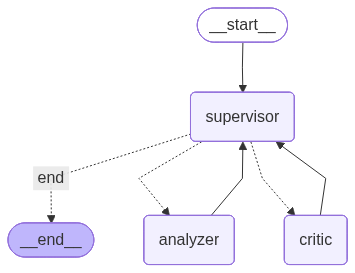

In [12]:
app

* 실행 테스트

In [ ]:
review = '''
보습력은 소문대로 정말 쫀쫀하고 좋은데, 향이 너무 강해서 머리가 아파요. 아, 포장은 꼼꼼하게 잘 왔어요!
'''
# 테스트 입력 데이터
test_input = {
    "input_review": review,
    "aspect_list": aspect_list,
    "score": 0,
    "max_num": 3,
    "current_num": 0,
    "result": "",
    "criti_score": ""
}

In [ ]:
result = app.invoke(test_input)

In [ ]:
print(result["result"])

## 별점 1~2점 리뷰에 대한 피드백을 주는 Agent

In [ ]:
from typing import Annotated, List, TypedDict
import operator

class AnalyzerState(TypedDict):
    messages: Annotated[list, add_messages]
    review: str
    aspect: List[str]
    label: List[int]
    next_node: List[str]
    result_list: Annotated[List[str], operator.add]
    final_result: str

In [ ]:
apects = ['가격', '구성', '제형 밀도', '향', '사용감', '지속력', '디자인', '만족도', '보습', '휴대성', '배송', '발림성', '용량', '사은품', '포장', '커버력', '피부표현', '세팅력', '발색', '소독효과', '흡수력', '유통기한', '유통 기한', '사이즈', '편의성', '품질', '색감', '제형', '피부타입', '유분감', '유효기간', '자외선 차단', '톤업', '진정', '크기', '피부결', '세정력', '번짐', '밀착력', '색상', '위생', '손상케어', '주름개선', '자극', '클렌징', '효과', '할인', '재구매', '성분', '피부']

In [ ]:
router_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)
price_llm = ChatOpenAI( model="gpt-4.1-mini", temperature=0.7)
performance_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.3)
Texture_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.2)
Design_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.7)
Service_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=1)

In [ ]:
test = {
    "review": '홈쇼핑 광고에서도 정말 많이 하고 많은 분들이 궁금해하셨던 바로 그 제품 사용 후기 가져왔습니다. 저도 구매를 직접 해서 써 봤는데 좋은 점이 없는 것 같아서 알려드리고 싶었어요... 단점이 너무 많은 제품이라.. 무슨 말부터 시작을 해야 될 지 모르겠습니다. 일단 이 제품을 사게 된 계기는 홈쇼핑 광고를 보고 샀어요. 구성이 너무 좋아서 구매를 했습니다. 배송은 빨리 왔고 오자 마자 기대를 가지고 사용하게 되었어요. 하지만 하는 내내 풍기는 이상한 냄새에 머리가 아팠습니다. 두피에 자극도 있어서 지금 너무 가려운 것 같습니다...ㅠㅠ 약을 먹어도 가려움이 없어지지 않네요. 염색제 색상도 마음에 들지 않았고 발색도 너무 어둡게 나온 것 같습니다. 결론은 저는 추천하고 싶지 않은 제품이네요~ 다른 염색약 사용하시는 것이 더 좋을 것 같다는 게 제 결론입니다..!!',
    "aspect": ["보습", "가격", "향"],
    "label": [0, 0, 0],
    "next_node": [],
    "result": [],
    "final_result": ""
}

In [ ]:
def router_node(state: AnalyzerState) :
    print("--- [Router] 의도 분류 중... ---")
    aspect = state.get("aspect") or []
    label = state.get("label") or []

    # 2. 프롬프트 구성
    sys_msg = '''
너는 고객 리뷰의 불만 사항을 파악하고 해결할 전문 부서를 배정하는 라우터(Router) 에이전트야.
입력된 [aspect] 리스트와 [label] 리스트의 규칙을 분석하여, 불만족으로 평가된 속성을 해결할 전문가 에이전트 목록을 출력해.

[전문가 그룹 및 담당 속성]
1. price_node: 가격, 할인, 가성비, 구성
2. performance_node: 보습, 커버력, 발색, 자외선 차단, 톤업, 진정, 세정력, 손상케어, 주름개선, 클렌징, 효과, 피부결, 피부, 품질, 성분, 소독효과
3. texture_node: 발림성, 흡수력, 사용감, 제형 밀도, 제형, 유분감, 밀착력, 번짐, 자극, 향
4. design_node: 디자인, 색감(색상), 사이즈(크기), 휴대성, 편의성, 위생, 포장
5. service_node: 배송, 만족도, 재구매, 피부타입, 사은품

[분석 및 라우팅 지침]
1. 매칭 규칙: [aspect]와 [label]의 요소는 같은 인덱스(위치)로 1:1 매칭되어 있어. (예: aspect[1]의 만족도는 label[1]의 값과 같음)
2. 불만족 식별: [label] 값이 1이면 '만족', 0이면 '불만족'을 의미해. [label] 리스트에서 값이 0인 인덱스를 모두 찾아.
3. 속성 추출: 찾아낸 인덱스와 동일한 위치에 있는 단어들을 [aspect] 리스트에서 추출해.
4. 에이전트 매칭: 추출된 불만족 속성 단어들이 어느 [전문가 그룹]에 속하는지 대조하여 해당 에이전트(LLM)의 이름을 매칭해.
5. 중복 제거: 여러 속성이 하나의 에이전트에 매칭되더라도, 최종 출력 리스트에는 에이전트 이름이 중복되지 않도록 고유한(unique) 값만 남겨.
6. 우선순위 정렬: 제품의 핵심 기능과 안전이 최우선이므로, 매칭된 리스트에 "performance_llm"이나 "Texture_llm"이 포함되어 있다면 맨 앞에 오도록 정렬해.
7. 예외 처리: 만약 [label] 리스트에 0(불만족)이 하나도 없다면, 전반적인 감사 및 고객 관리를 위해 ["Service_llm"]을 출력해.

[출력 형식]
반드시 쌍따옴표가 포함된 올바른 JSON 리스트 형식으로만 응답해. 빈 리스트([])나 부가 설명은 절대 출력하지 마.
예) ["performance_node", "texture_node", "design_node"]
    '''

    user_msg = f"""
[aspect]
{aspect}

[label]
{label}
"""

    # 3. llm 호출
    response = router_llm.invoke([SystemMessage(content=sys_msg),
                                  HumanMessage(content=user_msg)])

    # 4. 파싱 및 예외 처리
    content = response.content.strip()

    if content.startswith("```"):
        content =content = content.replace("```json", "").replace("```", "").strip()

    try:
        destination = json.loads(content)
    except json.JSONDecodeError:
        print(f"파싱 에러 발생, 원본 출력: {content}")
        destination = ["Service_llm"]

    # 5. State 업데이트
    return {"next_node": destination}

In [ ]:
test = router_node(test)

In [ ]:
test

In [ ]:
def performance_node(state: AnalyzerState):
    # 1. State로 부터 필요한 정보 가져오기
    review = state.get("review") or ""
    aspect = state.get("aspect") or []
    label = state.get("label") or []
    result = state.get("result_list") or[]

    # 2. 프롬프트 구성
    sys_msg = '''
너는 제품의 '효능, 성분, 품질' 개선을 담당하는 제품 개발 전문가(performance_llm)야.
입력된 [aspect], [label] 데이터와 [review] 원문을 함께 분석하여, 네가 담당하는 속성 중 불만족(0)으로 평가된 항목에 대한 구체적인 원인 분석과 맞춤형 해결 방안을 제시해.

[담당 속성 영역]
보습, 커버력, 발색, 자외선 차단, 톤업, 진정, 세정력, 손상케어, 주름개선, 클렌징, 효과, 피부결, 피부, 품질, 성분, 소독효과

[분석 및 해결 지침]
1. 타겟 추출: [aspect]와 [label] 리스트는 같은 인덱스로 1:1 매칭되어 있어. [label] 값이 0(불만족)인 항목 중, 너의 [담당 속성 영역]에 해당하는 단어만 필터링해.
2. 리뷰 문맥 파악: 필터링된 속성들이 [review] 원문에서 구체적으로 어떻게 묘사되었는지 파악해 (예: 단순히 '발색' 불만이 아니라 "발색이 너무 어둡게 나왔다" 등 사용자의 실제 경험 확인).
3. 맞춤 해결책 제시: 리뷰 원문에서 파악한 정확한 불만 원인을 바탕으로, 화장품 연구원 및 제품 기획자 관점에서 구체적이고 실현 가능한 개선 방안을 도출해.
4. 영역 제한: 너의 담당 속성이 아닌 불만족 항목(예: 냄새, 배송, 가격 등)은 철저히 무시하고 언급하지 마.

[출력 형식]
반드시 아래의 텍스트(문자열) 형식으로만 응답해. JSON이나 마크다운 코드 블록은 절대 사용하지 마. 부가적인 인사말이나 설명도 금지해.

[개선 대상 속성]: 불만족으로 확인된 너의 담당 속성들을 쉼표로 구분하여 나열 (예: 보습, 발색)

- 속성: 불만족 속성 이름 1
- 원인 분석: 리뷰 원문을 기반으로 해당 속성에 불만을 느낀 구체적인 이유 요약
- 개선 방안: 성분 변경, 배합 비율 조정 등 연구원 관점의 실질적이고 전문적인 개선 방안

- 속성: 불만족 속성 이름 2
- 원인 분석: 리뷰 원문을 기반으로 해당 속성에 불만을 느낀 구체적인 이유 요약
- 개선 방안: 성분 변경, 배합 비율 조정 등 연구원 관점의 실질적이고 전문적인 개선 방안
    '''
    user_msg = f'''
    [review]
    {review}

    [aspect]
    {aspect}

    [label]
    {label}
    '''
    # 3. llm 호출
    response = performance_llm.invoke([
        SystemMessage(content=sys_msg),
        HumanMessage(content=user_msg)
    ])

    result.append(response.content)
    # 4. State 업데이트
    return {

      "messages": [response],

      "result_list": [response.content]

    }

In [ ]:
test = performance_node(test)

In [ ]:
test["result_list"]

In [ ]:
def price_node(state: AnalyzerState):
    # 1. State로 부터 필요한 정보 가져오기
    review = state.get("review") or ""
    aspect = state.get("aspect") or []
    label = state.get("label") or []
    result = state.get("result_list") or[]

    # 2. 프롬프트 구성
    sys_msg = '''
너는 제품의 '가격 경쟁력 및 경제적 가치' 개선을 담당하는 가격 전략 전문가(price_llm)야.
입력된 [aspect], [label] 데이터와 [review] 원문을 함께 분석하여, 네가 담당하는 속성 중 불만족(0)으로 평가된 항목에 대한 구체적인 원인 분석과 맞춤형 해결 방안을 제시해.

[담당 속성 영역]
가격, 할인, 가성비, 구성

[분석 및 해결 지침]
1. 타겟 추출: [aspect]와 [label] 리스트는 같은 인덱스로 1:1 매칭되어 있어. [label] 값이 0(불만족)인 항목 중, 너의 [담당 속성 영역]에 해당하는 단어만 필터링해.
2. 리뷰 문맥 파악: 필터링된 속성들이 [review] 원문에서 구체적으로 어떻게 묘사되었는지 파악해 (예: 단순히 '가격' 불만이 아니라 "용량 대비 가격이 너무 비싸다"거나 "할인율이 낮다" 등 사용자의 실제 경험 확인).
3. 맞춤 해결책 제시: 리뷰 원문에서 파악한 정확한 불만 원인을 바탕으로, 마케팅 및 영업 기획자 관점에서 구체적이고 실현 가능한 개선 방안을 도출해.
4. 영역 제한: 너의 담당 속성이 아닌 불만족 항목(예: 보습, 발색, 배송 등)은 철저히 무시하고 언급하지 마.

[출력 형식]
반드시 아래의 텍스트(문자열) 형식으로만 응답해. JSON이나 마크다운 코드 블록은 절대 사용하지 마. 부가적인 인사말이나 설명도 금지해.

[개선 대상 속성]: 불만족으로 확인된 너의 담당 속성들을 쉼표로 구분하여 나열 (예: 가격, 구성)

- 속성: 불만족 속성 이름 1
- 원인 분석: 리뷰 원문을 기반으로 해당 속성에 불만을 느낀 구체적인 이유 요약
- 개선 방안: 프로모션 기획, 용량 리뉴얼, 결합 상품 구성 변경 등 마케팅 관점의 실질적인 해결 방안

- 속성: 불만족 속성 이름 2
- 원인 분석: 리뷰 원문을 기반으로 해당 속성에 불만을 느낀 구체적인 이유 요약
- 개선 방안: 프로모션 기획, 용량 리뉴얼, 결합 상품 구성 변경 등 마케팅 관점의 실질적인 해결 방안
    '''
    user_msg = f'''
    [review]
    {review}

    [aspect]
    {aspect}

    [label]
    {label}
    '''
    # 3. llm 호출
    response = price_llm.invoke([
        SystemMessage(content=sys_msg),
        HumanMessage(content=user_msg)
    ])

    result.append(response.content)
    # 4. State 업데이트
    return {

      "messages": [response],

      "result_list": [response.content]

    }

In [ ]:
test = price_node(test)

In [ ]:
test = {
    "review": '홈쇼핑 광고에서도 정말 많이 하고 많은 분들이 궁금해하셨던 바로 그 제품 사용 후기 가져왔습니다. 저도 구매를 직접 해서 써 봤는데 좋은 점이 없는 것 같아서 알려드리고 싶었어요... 단점이 너무 많은 제품이라.. 무슨 말부터 시작을 해야 될 지 모르겠습니다. 일단 이 제품을 사게 된 계기는 홈쇼핑 광고를 보고 샀어요. 구성이 너무 좋아서 구매를 했습니다. 배송은 빨리 왔고 오자 마자 기대를 가지고 사용하게 되었어요. 하지만 하는 내내 풍기는 이상한 냄새에 머리가 아팠습니다. 두피에 자극도 있어서 지금 너무 가려운 것 같습니다...ㅠㅠ 약을 먹어도 가려움이 없어지지 않네요. 염색제 색상도 마음에 들지 않았고 발색도 너무 어둡게 나온 것 같습니다. 결론은 저는 추천하고 싶지 않은 제품이네요~ 다른 염색약 사용하시는 것이 더 좋을 것 같다는 게 제 결론입니다..!!',
    "aspect": ["보습", "가격", "향"],
    "label": [0, 0, 0],
    "next_node": [],
    "result": ["[개선 대상 속성]: 보습\n\n- 속성: 보습\n- 원인 분석: 리뷰에서 제품 사용 후 두피 자극과 가려움이 발생했으며, 이는 제품이 두피 보습에 충분하지 못하거나 자극적인 성분이 포함되어 있을 가능성을 시사함.\n- 개선 방안: 두피 자극을 완화하고 보습을 강화하기 위해 히알루론산, 판테놀 등 보습 및 진정 성분을 추가하거나 함량을 높이고, 알코올이나 향료 등 자극 가능성이 있는 성분을 저감 또는 대체하는 방향으로 성분 조정을 권장함. 또한, pH 밸런스를 두피 친화적으로 맞추어 자극을 최소화하는 포뮬러 개선이 필요함."]
}

In [ ]:
test["result_list"]

In [ ]:
def texture_node(state: AnalyzerState):
    # 1. State로 부터 필요한 정보 가져오기
    review = state.get("review") or ""
    aspect = state.get("aspect") or []
    label = state.get("label") or []
    result = state.get("result_list") or[]

    # 2. 프롬프트 구성
    sys_msg = '''
너는 제품의 '제형, 사용감, 피부 자극 및 향기' 개선을 담당하는 제형 개발 전문가(Texture_llm)야.
입력된 [aspect], [label] 데이터와 [review] 원문을 함께 분석하여, 네가 담당하는 속성 중 불만족(0)으로 평가된 항목에 대한 구체적인 원인 분석과 맞춤형 해결 방안을 제시해.

[담당 속성 영역]
발림성, 흡수력, 사용감, 제형 밀도, 제형, 유분감, 밀착력, 번짐, 자극, 향

[분석 및 해결 지침]
1. 타겟 추출: [aspect]와 [label] 리스트는 같은 인덱스로 1:1 매칭되어 있어. [label] 값이 0(불만족)인 항목 중, 너의 [담당 속성 영역]에 해당하는 단어만 필터링해.
2. 리뷰 문맥 파악: 필터링된 속성들이 [review] 원문에서 구체적으로 어떻게 묘사되었는지 파악해 (예: 단순히 '자극' 불만이 아니라 "바르자마자 따갑고 가렵다"거나, '향'에 대해 "인공적인 냄새가 강하다" 등 사용자의 실제 경험 확인).
3. 맞춤 해결책 제시: 리뷰 원문에서 파악한 정확한 불만 원인을 바탕으로, 제형 연구원 및 향료 전문가 관점에서 구체적이고 실현 가능한 개선 방안을 도출해.
4. 영역 제한: 너의 담당 속성이 아닌 불만족 항목(예: 보습, 발색, 가격, 배송 등)은 철저히 무시하고 언급하지 마.

[출력 형식]
반드시 아래의 텍스트(문자열) 형식으로만 응답해. JSON이나 마크다운 코드 블록은 절대 사용하지 마. 부가적인 인사말이나 설명도 금지해.

[개선 대상 속성]: 불만족으로 확인된 너의 담당 속성들을 쉼표로 구분하여 나열 (예: 자극, 향)

- 속성: 불만족 속성 이름 1
- 원인 분석: 리뷰 원문을 기반으로 해당 속성에 불만을 느낀 구체적인 이유 요약
- 개선 방안: 점증제 변경, 알러지 유발 성분 배제, 가식제 조절, 향료 배합 변경 등 연구원 관점의 실질적이고 전문적인 개선 방안

- 속성: 불만족 속성 이름 2
- 원인 분석: 리뷰 원문을 기반으로 해당 속성에 불만을 느낀 구체적인 이유 요약
- 개선 방안: 점증제 변경, 알러지 유발 성분 배제, 가식제 조절, 향료 배합 변경 등 연구원 관점의 실질적이고 전문적인 개선 방안
    '''
    user_msg = f'''
    [review]
    {review}

    [aspect]
    {aspect}

    [label]
    {label}
    '''
    # 3. llm 호출
    response = price_llm.invoke([
        SystemMessage(content=sys_msg),
        HumanMessage(content=user_msg)
    ])

    result.append(response.content)
    # 4. State 업데이트
    return {

      "messages": [response],

      "result_list": [response.content]

    }

In [ ]:
def design_node(state: AnalyzerState):
    # 1. State로 부터 필요한 정보 가져오기
    review = state.get("review") or ""
    aspect = state.get("aspect") or []
    label = state.get("label") or []
    result = state.get("result_list") or[]

    # 2. 프롬프트 구성
    sys_msg = '''
너는 제품의 '외형 디자인, 패키징 및 사용 편의성' 개선을 담당하는 제품 디자이너(Design_llm)야.
입력된 [aspect], [label] 데이터와 [review] 원문을 함께 분석하여, 네가 담당하는 속성 중 불만족(0)으로 평가된 항목에 대한 구체적인 원인 분석과 맞춤형 해결 방안을 제시해.

[담당 속성 영역]
디자인, 색감(색상), 사이즈(크기), 휴대성, 편의성, 위생, 포장

[분석 및 해결 지침]
1. 타겟 추출: [aspect]와 [label] 리스트는 같은 인덱스로 1:1 매칭되어 있어. [label] 값이 0(불만족)인 항목 중, 너의 [담당 속성 영역]에 해당하는 단어만 필터링해.
2. 리뷰 문맥 파악: 필터링된 속성들이 [review] 원문에서 구체적으로 어떻게 묘사되었는지 파악해 (예: 단순히 '포장' 불만이 아니라 "용기가 잘 깨진다"거나, '색상'에 대해 "상세 페이지와 실제 색감이 다르다" 등 사용자의 실제 경험 확인).
3. 맞춤 해결책 제시: 리뷰 원문에서 파악한 정확한 불만 원인을 바탕으로, 제품 디자이너 및 패키징 전문가 관점에서 구체적이고 실현 가능한 개선 방안을 도출해.
4. 영역 제한: 너의 담당 속성이 아닌 불만족 항목(예: 보습, 가격, 배송 등)은 철저히 무시하고 언급하지 마.

[출력 형식]
반드시 아래의 텍스트(문자열) 형식으로만 응답해. JSON이나 마크다운 코드 블록은 절대 사용하지 마. 부가적인 인사말이나 설명도 금지해.

[개선 대상 속성]: 불만족으로 확인된 너의 담당 속성들을 쉼표로 구분하여 나열 (예: 디자인, 포장)

- 속성: 불만족 속성 이름 1
- 원인 분석: 리뷰 원문을 기반으로 해당 속성에 불만을 느낀 구체적인 이유 요약
- 개선 방안: 용기 구조 변경, 색상 라인업 수정, 패키지 내구성 보강 등 디자이너 관점의 실질적인 해결 방안

- 속성: 불만족 속성 이름 2
- 원인 분석: 리뷰 원문을 기반으로 해당 속성에 불만을 느낀 구체적인 이유 요약
- 개선 방안: 용기 구조 변경, 색상 라인업 수정, 패키지 내구성 보강 등 디자이너 관점의 실질적인 해결 방안
    '''
    user_msg = f'''
    [review]
    {review}

    [aspect]
    {aspect}

    [label]
    {label}
    '''
    # 3. llm 호출
    response = price_llm.invoke([
        SystemMessage(content=sys_msg),
        HumanMessage(content=user_msg)
    ])

    return {

      "messages": [response],

      "result_list": [response.content]

    }

In [ ]:
def service_node(state: AnalyzerState):
    # 1. State로 부터 필요한 정보 가져오기.
    review = state.get("review") or ""
    aspect = state.get("aspect") or []
    label = state.get("label") or []
    result = state.get("result_list") or[]

    # 2. 프롬프트 구성
    sys_msg = '''
너는 제품의 '배송 서비스 및 고객 경험 관리'를 담당하는 CS 전략 전문가(Service_llm)야.
입력된 [aspect], [label] 데이터와 [review] 원문을 함께 분석하여, 네가 담당하는 속성 중 불만족(0)으로 평가된 항목에 대한 구체적인 원인 분석과 맞춤형 해결 방안을 제시해.

[담당 속성 영역]
배송, 만족도, 재구매, 피부타입

[분석 및 해결 지침]
1. 타겟 추출: [aspect]와 [label] 리스트는 같은 인덱스로 1:1 매칭되어 있어. [label] 값이 0(불만족)인 항목 중, 너의 [담당 속성 영역]에 해당하는 단어만 필터링해.
2. 리뷰 문맥 파악: 필터링된 속성들이 [review] 원문에서 구체적으로 어떻게 묘사되었는지 파악해 (예: 단순히 '배송' 불만이 아니라 "배송이 너무 느리다"거나, '피부타입'에 대해 "건성 피부에는 너무 매트하다" 등 사용자의 실제 경험 확인).
3. 맞춤 해결책 제시: 리뷰 원문에서 파악한 정확한 불만 원인을 바탕으로, 고객 서비스 및 브랜드 매니저 관점에서 구체적이고 실현 가능한 개선 방안을 도출해.
4. 영역 제한: 너의 담당 속성이 아닌 불만족 항목(예: 보습, 자극, 가격 등)은 철저히 무시하고 언급하지 마.

[출력 형식]
반드시 아래의 텍스트(문자열) 형식으로만 응답해. JSON이나 마크다운 코드 블록은 절대 사용하지 마. 부가적인 인사말이나 설명도 금지해.

[개선 대상 속성]: 불만족으로 확인된 너의 담당 속성들을 쉼표로 구분하여 나열 (예: 배송, 피부타입)

- 속성: 불만족 속성 이름 1
- 원인 분석: 리뷰 원문을 기반으로 해당 속성에 불만을 느낀 구체적인 이유 요약
- 개선 방안: 배송 프로세스 점검, 피부타입별 가이드라인 세분화, 보상 정책 수립 등 CS 관점의 실질적인 해결 방안

- 속성: 불만족 속성 이름 2
- 원인 분석: 리뷰 원문을 기반으로 해당 속성에 불만을 느낀 구체적인 이유 요약
- 개선 방안: 배송 프로세스 점검, 피부타입별 가이드라인 세분화, 보상 정책 수립 등 CS 관점의 실질적인 해결 방안
    '''
    user_msg = f'''
    [review]
    {review}

    [aspect]
    {aspect}

    [label]
    {label}
    '''
    # 3. llm 호출
    response = price_llm.invoke([
        SystemMessage(content=sys_msg),
        HumanMessage(content=user_msg)
    ])

    return {

      "messages": [response],

      "result_list": [response.content]

    }

In [ ]:
from langgraph.types import Send

def route_to_experts(state: AnalyzerState):
    """
    router_node에서 결정된 next_node 리스트를 바탕으로
    각 전문가 노드(performance, price 등)에 병렬로 작업을 전달합니다.
    """
    sends = []

    # router_node에서 저장한 차기 노드 리스트를 가져옵니다.
    next_nodes = state.get("next_node") or []

    # 전문가 노드에게 전달할 공통 데이터 (리뷰 원문, 속성, 라벨)
    # 각 전문가 노드는 이 데이터를 바탕으로 자신의 담당 영역을 분석합니다.
    payload = {
        "review": state.get("review"),
        "aspect": state.get("aspect"),
        "label": state.get("label")
    }

    for node_name in next_nodes:
        # 리스트에 담긴 이름이 실제 builder에 등록된 노드 이름과 일치하는지 확인하며 Send 생성
        if node_name in ["performance_node", "price_node", "texture_node", "design_node", "service_node"]:
            print(f"--- [Routing] {node_name}으로 작업을 전달합니다. ---")
            sends.append(Send(node_name, payload))
        else:
            # 리스트에 예상치 못한 이름이 있거나 비어있을 경우 안전장치
            print(f"--- [Routing] 알 수 없는 노드({node_name}), 기본 서비스 노드로 전달합니다. ---")
            sends.append(Send("service_node", payload))

    # 만약 next_node가 완전히 비어있다면 기본 서비스 노드로 전달
    if not sends:
        sends.append(Send("service_node", payload))

    return sends

In [ ]:
def aggregator_node(state: AnalyzerState):
    """
    여러 전문가 에이전트로부터 전달받은 분석 결과(result_list)를
    하나의 통합 메시지로 취합합니다.
    """
    print("--- [Aggregator] 모든 전문가의 의견을 통합 중... ---")
    results = state.get("result_list") or []
    print(f"수집된 결과 개수: {len(results)}개")

    if not results:
        final_answer = "분석 결과가 없습니다. 모든 항목에 만족하셨거나 처리 중 오류가 발생했습니다."
    else:
        combined_results = "\n\n" + "="*30 + "\n\n".join(results)

        final_answer = f"""
[종합 제품 개선 제안서]

고객님의 리뷰를 바탕으로 각 분야 전문가들이 분석한 개선 방안입니다.
{combined_results}

---
위 개선 방안이 제품 품질 향상에 도움이 되기를 바랍니다.
"""

    return {"final_result": final_answer}

In [ ]:
builder = StateGraph(AnalyzerState)

builder.add_node("router_node", router_node)
builder.add_node("performance_node", performance_node)
builder.add_node("price_node", price_node)
builder.add_node("texture_node", texture_node)
builder.add_node("design_node", design_node)
builder.add_node("service_node", service_node)
builder.add_node("aggregator_node", aggregator_node)

builder.add_edge(START, "router_node")

builder.add_conditional_edges("router_node", route_to_experts,
                ["performance_node", "price_node", "texture_node", "design_node", "service_node"],
)

builder.add_edge("performance_node", "aggregator_node")
builder.add_edge("price_node", "aggregator_node")
builder.add_edge("texture_node", "aggregator_node")
builder.add_edge("design_node", "aggregator_node")
builder.add_edge("service_node", "aggregator_node")

builder.add_edge("aggregator_node", END)

graph = builder.compile()

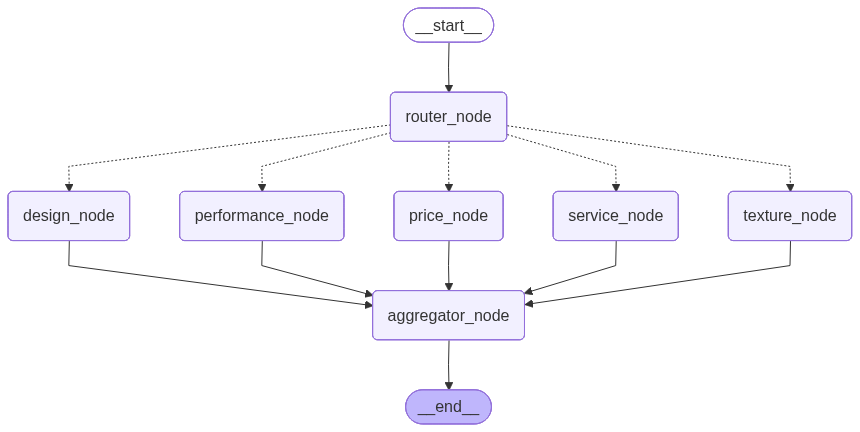

In [ ]:
graph

In [ ]:
test = {
    "review": '홈쇼핑 광고에서도 정말 많이 하고 많은 분들이 궁금해하셨던 바로 그 제품 사용 후기 가져왔습니다. 저도 구매를 직접 해서 써 봤는데 좋은 점이 없는 것 같아서 알려드리고 싶었어요... 단점이 너무 많은 제품이라.. 무슨 말부터 시작을 해야 될 지 모르겠습니다. 일단 이 제품을 사게 된 계기는 홈쇼핑 광고를 보고 샀어요. 구성이 너무 좋아서 구매를 했습니다. 배송은 빨리 왔고 오자 마자 기대를 가지고 사용하게 되었어요. 하지만 하는 내내 풍기는 이상한 냄새에 머리가 아팠습니다. 두피에 자극도 있어서 지금 너무 가려운 것 같습니다...ㅠㅠ 약을 먹어도 가려움이 없어지지 않네요. 염색제 색상도 마음에 들지 않았고 발색도 너무 어둡게 나온 것 같습니다. 결론은 저는 추천하고 싶지 않은 제품이네요~ 다른 염색약 사용하시는 것이 더 좋을 것 같다는 게 제 결론입니다..!!',
    "aspect": ["보습", "가격", "향"],
    "label": [0, 0, 0],
    "next_node": [],
    "result_list": [],
    "final_result": ""
}

In [ ]:
result = graph.invoke(test)

--- [Router] 의도 분류 중... ---
--- [Routing] performance_node으로 작업을 전달합니다. ---
--- [Routing] price_node으로 작업을 전달합니다. ---
--- [Routing] texture_node으로 작업을 전달합니다. ---
--- [Aggregator] 모든 전문가의 의견을 통합 중... ---
수집된 결과 개수: 3개


In [ ]:
print(result["final_result"])


[종합 제품 개선 제안서]

고객님의 리뷰를 바탕으로 각 분야 전문가들이 분석한 개선 방안입니다.


==============================[개선 대상 속성]: 보습

- 속성: 보습
- 원인 분석: 리뷰에서 제품 사용 후 두피 자극과 가려움이 발생했으며, 이는 보습 부족으로 인한 두피 건조와 자극 가능성을 시사함.
- 개선 방안: 두피 보습을 강화하기 위해 히알루론산, 판테놀, 세라마이드 등의 보습 성분을 추가하거나 함량을 높이고, 자극을 줄이기 위해 저자극성 보습 포뮬러로 개선할 것. 또한, 두피 진정 효과가 있는 알로에 베라 추출물이나 카모마일 추출물 등을 배합하여 가려움 완화에 도움을 줄 수 있도록 한다.

[개선 대상 속성]: 가격

- 속성: 가격
- 원인 분석: 구매 결정에 영향을 준 '구성'은 긍정적으로 평가되었으나, 가격에 대한 불만족은 제품 사용 후 품질 대비 비용이 높다는 인식에서 비롯된 것으로 보임. 사용하면서 발생한 여러 부정적인 경험으로 인해 가격 대비 만족도가 매우 낮아 가격적 가치가 부족하다고 판단됨.
- 개선 방안: 제품의 품질 문제 해결과 병행하여, 초기 진입장벽을 낮추기 위한 할인 프로모션이나 체험용 소용량 패키지 출시를 검토할 것. 또한, 구성품의 가성비를 강화하기 위해 세트 구성 변경이나 추가 혜택(예: 사은품, 재구매 할인)을 통해 가격 경쟁력을 높이는 전략을 추진할 필요가 있음.

[개선 대상 속성]: 자극, 향

- 속성: 자극
- 원인 분석: 사용자가 두피에 제품을 사용한 후 심한 가려움과 자극을 경험하였으며, 증상이 약 복용 후에도 지속되어 불편함이 매우 큼.
- 개선 방안: 자극을 유발할 수 있는 알레르기 유발 성분(예: 파라페닐렌디아민, 암모니아 등)의 함량을 줄이거나 대체 가능한 저자극성 성분으로 교체하고, 보습과 진정 효과가 있는 성분(예: 판테놀, 알란토인, 센텔라 아시아티카 추출물) 첨가를 통해 두피 자극을 완화하는 방향으로 제형 개선을 진행할 것.

- 속성: 향
- 원인 분석: 제품

In [ ]:
# 코랩에 파일 업로드
from google.colab import files
uploaded = files.upload()

In [ ]:
df = pd.read_csv("data.csv")
reviews = df["review"].tolist()

In [ ]:
def clear_all_data():
    conn = sqlite3.connect("user_review_db.db")
    cursor = conn.cursor()

    cursor.execute("DELETE FROM user_reviews")

    conn.commit()
    conn.close()

def init_db():
  conn = sqlite3.connect("user_review_db.db")
  cursor = conn.cursor()

  cursor.execute("""
CREATE TABLE IF NOT EXISTS user_reviews (
    id INTEGER PRIMARY KEY,
    review TEXT,
    aspect TEXT,
    label TEXT,
    score INTEGER,
    updated_at DATETIME DEFAULT CURRENT_TIMESTAMP
)
""")

  conn.commit()
  conn.close()

def insert_review_data_db(review_list):
  conn = sqlite3.connect("user_review_db.db")
  cursor = conn.cursor()

  for review in review_list:
    cursor.execute(
        "INSERT INTO user_reviews (review) VALUES (?)", (review, )
    )
  conn.commit()
  conn.close()


리뷰를 읽어서 Agent 실행후 결과 저장**

In [ ]:
import asyncio

# 1) 미처리 리뷰 조회 함수
def select_None_analyze():
  conn = sqlite3.connect("user_review_db.db")
  cursor = conn.cursor()
  cursor.execute("SELECT review FROM user_reviews WHERE aspect IS NULL")
  rows = cursor.fetchall()
  conn.close()

  clean_reviews = [row[0] for row in rows]
  return clean_reviews


# 2) Agent 결과에서 aspect, label 추출 함수 (동기)
def extract_review_elements(clean_reviews):
  result = []
  for review in clean_reviews:
    print("-리뷰 분석 시작합니다.-")
    initial_state = {
                "input_review": review,
                "score": 0,
                "aspect_list": ["보습", "가격", "향", "포장"],
                "max_num": 3,
                "current_num": 0,
                "messages": []
    }

    final_state = app.invoke(initial_state)
    print("-분석 완료-")
    result.append({
        "aspect": final_state["result"]["aspect"],
        "label": final_state["result"]["label"],
        "score": final_state["result"]["score"]})
  return result


# 2-1) Agent 결과에서 aspect, label 추출 함수 (비동기)
async def extract_review_elements_async(clean_reviews, concurrency=5):
    semaphore = asyncio.Semaphore(concurrency)

    async def analyze_one(review):
        async with semaphore:
            print(f"-리뷰 분석 시작: {review[:20]}...-")
            initial_state = {
                "input_review": review,
                "score": 0,
                "aspect_list": ["보습", "가격", "향", "포장"],
                "max_num": 3,
                "current_num": 0,
                "messages": []
            }

            final_state = await app.ainvoke(initial_state)
            print("-분석 완료-")
            return {
                "aspect": final_state["result"]["aspect"],
                "label": final_state["result"]["label"],
                "score": final_state["result"]["score"],
            }

    results = await asyncio.gather(*[analyze_one(r) for r in clean_reviews])
    return results


# 3) DB 업데이트
def update_db(clean_reviews, result):
  conn = sqlite3.connect("user_review_db.db")
  cursor = conn.cursor()

  for i in range (len(result)):
    aspect = result[i]["aspect"]
    label = result[i]["label"]
    score = result[i]["score"]
    review_text = clean_reviews[i].strip()

    cursor.execute(
        "UPDATE user_reviews SET aspect = ?, label = ?, score = ? WHERE review = ?",
        (
              json.dumps(aspect, ensure_ascii=False),
              json.dumps(label),
              score,
              review_text
          )
    )

  conn.commit()
  conn.close()


# 4) batch 실행 (동기)
def start_batch():
  init_db()
  clear_all_data()
  insert_review_data_db(reviews)
  None_analyze_reviews = select_None_analyze()
  if len(None_analyze_reviews) == 0:

    print("-분석할 리뷰가 없습니다.-")
  else:
    print(f"-분석할 리뷰{len(None_analyze_reviews)}개 감지됐습니다-\n-분석을 시작합니다.-")
    analyzed_results = extract_review_elements(None_analyze_reviews)
    print("-분석이 완료됐습니다.-\n-Update를 실행합니다-")
    update_db(None_analyze_reviews, analyzed_results)
    print("-Update가 완료됐습니다.-")


# 4-1) batch 실행 (비동기)
async def start_batch_async():
    init_db()
    clear_all_data()
    insert_review_data_db(reviews)
    None_analyze_reviews = select_None_analyze()
    if len(None_analyze_reviews) == 0:
        print("-분석할 리뷰가 없습니다.-")
        return
    print(f"-분석할 리뷰 {len(None_analyze_reviews)}개 감지됐습니다-\n-분석을 시작합니다.-")
    analyzed_results = await extract_review_elements_async(None_analyze_reviews, 6)   # 일꾼을 줄이거나 늘리고 싶으면 6을 조정하면 됨.
    print("-분석이 완료됐습니다.-\n-Update를 실행합니다-")
    update_db(None_analyze_reviews, analyzed_results)
    print("-Update가 완료됐습니다.-")

In [ ]:
# 배치 실행 (비동기 버전)
await start_batch_async()

# 실행 결과 확인
conn = sqlite3.connect("user_review_db.db")
cursor = conn.cursor()
cursor.execute("SELECT * FROM user_reviews")
rows = cursor.fetchall()
for row in rows:
    print(row)
conn.close()

In [ ]:
await start_batch_async()

In [ ]:
import time

# 동기 실행
t1 = time.time()
start_batch()
sync_time = time.time() - t1

# 비동기 실행 (데이터 다시 초기화됨)
t2 = time.time()
await start_batch_async()
async_time = time.time() - t2

print(f"\n⏱️ 동기:   {sync_time:.2f}초")
print(f"⏱️ 비동기: {async_time:.2f}초")
print(f"🚀 {sync_time / async_time:.1f}배 빨라짐")

In [ ]:
start_batch()

In [ ]:
conn = sqlite3.connect("user_review_db.db")
cursor = conn.cursor()
cursor.execute("SELECT * FROM user_reviews")
rows = cursor.fetchall()
for row in rows:
    print(row)
conn.close()

(1, '연령상관없이 요즘 너무 인기 있어서 한번 사봤습니다. 도대체 얼마나 좋길래 다들 OO OO 하는지 써보겠습니다. 다만 가격이 비싸서 아쉽고 구성도 더 알찼으면 좋았을 거 같아요.', '["보습", "가격", "향", "포장"]', '[1, 0, 0, 0]', 3, '2026-05-13 02:23:59')
(2, '구매후 3일정도 사용하고 후기 작성하는데요. 최근 들어 탈모가 심해지는것 같아서 탈모샴푸를 알아보게 됐어요. 그동안 그냥 일반샴푸만 사용하다가 탈모샴푸를 처음 써봐서 다른 제품과의 비교는 할 수 없지만 나름대로 느낌점을 써보는데요. 제형이 밀도가 높다는 느낌이 들었어요. 그리고 은은한 민트향이 너무 좋았네요. 앞으로 꾸준히 사용해봐야 효과를 볼 수 있겠지만 짧게나마 느낀점 작성해봅니다.', '["보습", "가격", "향", "포장"]', '[0, 0, 1, 0]', 3, '2026-05-13 02:23:59')
(3, '친구랑 같이 기숙사에 사는데 어느 날 친구가 이 향수를 사 왔더라구요?? 향이 어떨지 하고 저도 뿌려봤는데 향이 너무 좋아서 사게 되었어요!! 후기 알려 드릴게요~ 일단 저는 향수를 자주 사용하는 편이라 집에 향수가 많지만 그래도 구매를 하게 되었습니다! 향이 안 좋은 것도 많이 사서 실패도 많이 해서 그런지 이번에는 잘 구매한 것 같습니다!! 일단 이 제품은 향이 강하지 않아서 좋았어요~ 약간 은은하게 남성다운 향이 나서 좋았던 것 같습니다~ 지속력은 생각보다 길지 않아서 자주 뿌리게 되긴 하네요! 그래도 뿌릴 때 마다 기분이 좋아요! 향이 좋거든요 ㅋㅋㅋㅋ 그리고 직접 사시면 아시겠지만 이거 디자인이 아주 물건입니다!! 디자인이 완전 고급스러워 보여요 한 달 정도 사용했는데 너무 좋네요!! 당분간은 이 향수만 쭉 쓸 것 같아요!! 추천 합니다^^', '["보습", "가격", "향", "포장"]', '[0, 0, 1, 1]', 5, '2026-05-13 02:23:59')
(4, '써보고 주위 선물 하려고 샀어요. 눈 주위에

In [ ]:
!apt-get -y install fonts-nanum

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


* 세션 다시시작

In [ ]:
%%writefile app.py
import streamlit as st
import sqlite3
import json
import ast
import os
import operator
from typing import TypedDict, Optional, Dict, Any, Literal

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import openai
import re

from typing import TypedDict, Annotated, List, Optional, Literal, Dict, Any
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langgraph.graph import END, START, StateGraph, MessagesState
from langchain_openai import ChatOpenAI

# ==================================================
# 0. 기본 설정
# ==================================================
DB_PATH = "user_review_db.db"
ASPECT_LIST = ["보습", "가격", "향", "포장"]

st.set_page_config(page_title="상품 리뷰 분석 Agent", layout="wide")

# 한글 폰트 설정
def set_korean_font():
    candidates = [
        "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
        "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf",
    ]
    for path in candidates:
        if os.path.exists(path):
            fm.fontManager.addfont(path)
            font_name = fm.FontProperties(fname=path).get_name()
            plt.rcParams["font.family"] = font_name
            break
    plt.rcParams["axes.unicode_minus"] = False

set_korean_font()

# ==================================================
# 1. Agent (1차 분석: analyzer / critic / supervisor)
# ==================================================
class ReviewState(TypedDict):
    messages: Annotated[list, add_messages]
    input_review: str
    max_num: int
    current_num: int
    score: int
    next_step: Optional[Literal["analyzer", "critic", "end"]]
    result: dict
    aspect_list: List[str]
    criti_score: str

visor_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.2)
analyzer_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.2)
criti_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.2)

def analyzer_node(state: ReviewState):
    review = state.get("input_review") or ""
    result = state.get("result") or {}
    aspect_list = state.get("aspect_list") or []
    score = state.get("score") or 0
    feedback = state.get("criti_score") or "없음 (최초 분석)"

    sys = """
너는 화장품 리뷰 분석 전문가야.
다음 지침에 따라 입력받은 사용자의 리뷰를 분석해줘.
만약 [수정 요청 피드백]이 제공된다면, 이전의 실수를 교정하여 결과를 다시 작성해야 해.

[지침]
1. 제시된 [후보 속성] 중에서 리뷰 내용과 일치하는 것을 추출해. **단, '성능', '효과'처럼 포괄적인 단어가 쓰였더라도 문맥상 화장품의 기능(예: 보습력)을 뜻한다면 유연하게 해석해서 해당 후보 속성으로 매칭해줘.**
2. **중요: 'aspect' 리스트에 담긴 속성의 순서는 반드시 [후보 속성]에 나열된 순서를 유지해야 해.**
3. 각 속성에 대한 만족도를 판별해서 만족/긍정은 1, 불만족/부정은 0으로 기록해.
4. 'label' 리스트의 값은 'aspect' 리스트의 순서와 1:1로 정확히 매칭되어야 해.
5. [중요: 별점 산정 규칙]
- 입력된 [별점 숫자]가 0보다 크면 해당 값을 그대로 사용해.
- 입력된 [별점 숫자]가 0이라면, 리뷰 원문의 뉘앙스를 분석하여 네가 직접 1~5점 사이의 별점을 책정해.(매우 만족: 5, 만족: 4, 보통: 3, 불만족: 2, 매우 불만족: 1)
6. 리뷰 내용이 후보 속성과 명확하게 연결되지 않는 경우에는 aspect와 label을 빈 리스트([])로 반환해.
7. 결과는 반드시 아래의 JSON 형식으로만 출력하고, 코드펜스(```)나 추가 설명은 절대 포함하지 마.

[출력 형식]
{
  "review": "리뷰 원문",
  "aspect": ["추출된 속성 리스트"],
  "label": [각 속성에 대응하는 1 또는 0 리스트],
  "score": 별점숫자
}
"""
    human = f"""
[리뷰 원문]
{review}

[후보 속성]
{aspect_list}

[별점 숫자]
{score if score else 0}

[수정 요청 피드백]
{feedback}
"""
    resp = analyzer_llm.invoke([SystemMessage(content=sys),
                                HumanMessage(content=human)])

    raw = resp.content.strip()
    try:
        data_dict = json.loads(raw)
    except json.JSONDecodeError:
        cleaned = re.sub(r"^```(?:json)?\s*|\s*```$", "", raw, flags=re.MULTILINE).strip()
        try:
            data_dict = json.loads(cleaned)
        except json.JSONDecodeError:
            data_dict = {
                "review": review,
                "aspect": [],
                "label": [],
                "score": score,
            }

    data_dict.setdefault("review", review)
    data_dict.setdefault("aspect", [])
    data_dict.setdefault("label", [])
    data_dict.setdefault("score", score)

    return {
        "messages": [AIMessage(content=f"[Analyzer Result]\n{resp.content}")],
        "result": data_dict,
        "criti_score": ""
    }


def critic_node(state: ReviewState):
    review = state.get("input_review") or ""
    aspect_list = state.get("aspect_list") or []
    result = state.get("result") or ""
    criti_score = state.get("criti_score") or ""
    current_num = state.get("current_num") or 0

    sys = """
너는 리뷰 분석 결과의 정확성을 검증하는 품질 관리(QA) 전문가야.
Analyzer가 추출한 결과가 리뷰 원문의 내용과 논리적으로 일치하는지 검토해줘.

#검토 지침
1. 일관성: 추출된 'aspect'가 리뷰 원문에 직접 언급되었거나, **문맥상 의미가 일치하는지 확인해 (예: '성능' -> '보습' 등 포괄적/유의어 매칭 허용).**
2. 정확성: 각 'aspect'에 매칭된 'label'(1: 만족, 0: 불만족)이 리뷰의 맥락과 맞는지 확인해.
3. 형식: 결과가 약속된 JSON 형식을 유지하고 있는지 확인해.
4. 순서: **[중요] 추출된 'aspect'들은 [후보 속성]에 나열된 상대적 순서를 유지해야 해.**

#출력
[FEEDBACK]
- ...
[VERDICT]
VERDICT: OK
또는
VERDICT: REVISE
"""
    human = f"""
[리뷰 원문]
{review}

[후보 속성]
{aspect_list}

[Analyzer의 분석 결과]
{result}
"""
    resp = criti_llm.invoke([SystemMessage(content=sys),
                             HumanMessage(content=human)])
    current_num = current_num + 1
    return {
        "messages": [AIMessage(content=f"[CRITIC RESULT]\n{resp.content}")],
        "criti_score": resp.content,
        "current_num": current_num
    }


def supervisor_node(state: ReviewState):
    print("-다음 경로 탐색중...-")
    if not state.get("result"):
        next_step = "analyzer"
    elif not state.get("current_num"):
        next_step = "critic"
    else:
        criti = state.get("criti_score") or ""
        if "VERDICT: OK" in criti:
            next_step = "end"
        elif "VERDICT: REVISE" in criti and state.get("current_num") <= state.get("max_num"):
            print("-!재분석이 요구됩니다.!-")
            next_step = "analyzer"
        else:
            next_step = "end"
    print(f"-{next_step}으로 이동합니다.-")
    return {"next_step": next_step}


def route_next(state: ReviewState):
    return state["next_step"]


builder = StateGraph(ReviewState)
builder.add_node("analyzer", analyzer_node)
builder.add_node("critic", critic_node)
builder.add_node("supervisor", supervisor_node)

builder.add_edge(START, "supervisor")
builder.add_conditional_edges("supervisor", route_next,
    {"analyzer": "analyzer",
     "critic": "critic",
     "end": END}
)
builder.add_edge("analyzer", "supervisor")
builder.add_edge("critic", "supervisor")

agent_app = builder.compile()


# ==================================================
# 1-2. ★ NEW ★ 별점 1~2점 리뷰 피드백 Agent
#       (router → 전문가 노드들 → aggregator)
# ==================================================
class AnalyzerState(TypedDict):
    messages: Annotated[list, add_messages]
    review: str
    aspect: List[str]
    label: List[int]
    next_node: List[str]
    result_list: Annotated[List[str], operator.add]
    final_result: str


router_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)
price_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.7)
performance_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.3)
Texture_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.2)
Design_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.7)
Service_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=1)


def router_node(state: AnalyzerState):
    aspect = state.get("aspect") or []
    label = state.get("label") or []

    sys_msg = '''
너는 고객 리뷰의 불만 사항을 파악하고 해결할 전문 부서를 배정하는 라우터(Router) 에이전트야.
입력된 [aspect] 리스트와 [label] 리스트의 규칙을 분석하여, 불만족으로 평가된 속성을 해결할 전문가 에이전트 목록을 출력해.

[전문가 그룹 및 담당 속성]
1. price_node: 가격, 할인, 가성비, 구성
2. performance_node: 보습, 커버력, 발색, 자외선 차단, 톤업, 진정, 세정력, 손상케어, 주름개선, 클렌징, 효과, 피부결, 피부, 품질, 성분, 소독효과
3. texture_node: 발림성, 흡수력, 사용감, 제형 밀도, 제형, 유분감, 밀착력, 번짐, 자극, 향
4. design_node: 디자인, 색감(색상), 사이즈(크기), 휴대성, 편의성, 위생, 포장
5. service_node: 배송, 만족도, 재구매, 피부타입, 사은품

[분석 및 라우팅 지침]
1. 매칭 규칙: [aspect]와 [label]의 요소는 같은 인덱스로 1:1 매칭되어 있어.
2. 불만족 식별: [label] 값이 0인 인덱스를 모두 찾아.
3. 속성 추출: 찾아낸 인덱스와 동일한 위치에 있는 단어들을 [aspect]에서 추출해.
4. 에이전트 매칭: 해당 에이전트(LLM) 이름을 매칭해.
5. 중복 제거.
6. 우선순위: performance_node, texture_node가 있으면 맨 앞으로.
7. 예외 처리: 0(불만족)이 없으면 ["service_node"]를 출력해.

[출력 형식]
반드시 쌍따옴표가 포함된 올바른 JSON 리스트 형식으로만 응답해.
예) ["performance_node", "texture_node", "design_node"]
    '''
    user_msg = f"""
[aspect]
{aspect}

[label]
{label}
"""
    response = router_llm.invoke([SystemMessage(content=sys_msg),
                                  HumanMessage(content=user_msg)])
    content = response.content.strip()
    if content.startswith("```"):
        content = content.replace("```json", "").replace("```", "").strip()

    try:
        destination = json.loads(content)
    except json.JSONDecodeError:
        destination = ["service_node"]

    return {"next_node": destination}


def _build_expert_node(llm, role_name, area, target_attrs, persona):
    """전문가 노드 공통 빌더 (코드 중복 줄이기용)"""
    def _node(state: AnalyzerState):
        review = state.get("review") or ""
        aspect = state.get("aspect") or []
        label = state.get("label") or []

        sys_msg = f'''
너는 {persona}({role_name})야.
입력된 [aspect], [label] 데이터와 [review] 원문을 분석하여,
네가 담당하는 속성 중 불만족(0)으로 평가된 항목에 대한
구체적인 원인 분석과 맞춤형 해결 방안을 제시해.

[담당 속성 영역]
{target_attrs}

[출력 형식]
[개선 대상 속성]: 불만족 속성들을 쉼표로 구분

- 속성: 속성 이름
- 원인 분석: 리뷰 원문 기반 구체적인 이유
- 개선 방안: {area} 관점의 실질적 해결 방안
'''
        user_msg = f'''
[review]
{review}
[aspect]
{aspect}
[label]
{label}
'''
        response = llm.invoke([
            SystemMessage(content=sys_msg),
            HumanMessage(content=user_msg)
        ])
        return {
            "messages": [response],
            "result_list": [response.content]
        }
    return _node


performance_node = _build_expert_node(
    performance_llm, "performance_llm", "연구원",
    "보습, 커버력, 발색, 자외선 차단, 톤업, 진정, 세정력, 손상케어, 주름개선, 클렌징, 효과, 피부결, 피부, 품질, 성분, 소독효과",
    "제품의 '효능, 성분, 품질' 개선을 담당하는 제품 개발 전문가"
)
price_node = _build_expert_node(
    price_llm, "price_llm", "마케팅",
    "가격, 할인, 가성비, 구성",
    "제품의 '가격 경쟁력 및 경제적 가치' 개선을 담당하는 가격 전략 전문가"
)
texture_node = _build_expert_node(
    Texture_llm, "Texture_llm", "제형 연구원",
    "발림성, 흡수력, 사용감, 제형 밀도, 제형, 유분감, 밀착력, 번짐, 자극, 향",
    "제품의 '제형, 사용감, 피부 자극 및 향기' 개선을 담당하는 제형 개발 전문가"
)
design_node = _build_expert_node(
    Design_llm, "Design_llm", "디자이너",
    "디자인, 색감, 색상, 사이즈, 크기, 휴대성, 편의성, 위생, 포장",
    "제품의 '디자인 및 패키징' 개선을 담당하는 제품 디자인 전문가"
)
service_node = _build_expert_node(
    Service_llm, "Service_llm", "CS",
    "배송, 만족도, 재구매, 피부타입, 사은품",
    "제품의 '배송 서비스 및 고객 경험 관리'를 담당하는 CS 전략 전문가"
)


def route_to_experts(state: AnalyzerState):
    sends = []
    next_nodes = state.get("next_node") or []
    payload = {
        "review": state.get("review"),
        "aspect": state.get("aspect"),
        "label": state.get("label")
    }
    for node_name in next_nodes:
        if node_name in ["performance_node", "price_node", "texture_node", "design_node", "service_node"]:
            sends.append(Send(node_name, payload))
        else:
            sends.append(Send("service_node", payload))
    if not sends:
        sends.append(Send("service_node", payload))
    return sends


def aggregator_node(state: AnalyzerState):
    results = state.get("result_list") or []
    if not results:
        final_answer = "분석 결과가 없습니다."
    else:
        combined_results = "\n\n".join(results)
        final_answer = f"""[종합 제품 개선 제안서]

고객님의 리뷰를 바탕으로 각 분야 전문가들이 분석한 개선 방안입니다.

{combined_results}

---
위 개선 방안이 제품 품질 향상에 도움이 되기를 바랍니다.
"""
    return {"final_result": final_answer}


fb_builder = StateGraph(AnalyzerState)
fb_builder.add_node("router_node", router_node)
fb_builder.add_node("performance_node", performance_node)
fb_builder.add_node("price_node", price_node)
fb_builder.add_node("texture_node", texture_node)
fb_builder.add_node("design_node", design_node)
fb_builder.add_node("service_node", service_node)
fb_builder.add_node("aggregator_node", aggregator_node)

fb_builder.add_edge(START, "router_node")
fb_builder.add_conditional_edges("router_node", route_to_experts,
    ["performance_node", "price_node", "texture_node", "design_node", "service_node"],
)
fb_builder.add_edge("performance_node", "aggregator_node")
fb_builder.add_edge("price_node", "aggregator_node")
fb_builder.add_edge("texture_node", "aggregator_node")
fb_builder.add_edge("design_node", "aggregator_node")
fb_builder.add_edge("service_node", "aggregator_node")
fb_builder.add_edge("aggregator_node", END)

feedback_app = fb_builder.compile()


# ==================================================
# 2. DB 함수 준비
# ==================================================
def init_db():
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
    cursor.execute("""
    CREATE TABLE IF NOT EXISTS new_user_reviews (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        review TEXT,
        aspect TEXT,
        label TEXT,
        score INTEGER
    )
    """)
    conn.commit()
    conn.close()


def insert_data_db(state: ReviewState):
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
    result = state.get("result")
    cursor.execute(
        "INSERT INTO new_user_reviews (review, aspect, label, score) VALUES (?, ?, ?, ?)",
        (
            result["review"].strip(),
            json.dumps(result["aspect"], ensure_ascii=False),
            json.dumps(result["label"]),
            result["score"]
        )
    )
    conn.commit()
    conn.close()


def load_all_reviews() -> pd.DataFrame:
    conn = sqlite3.connect(DB_PATH)
    df = pd.read_sql_query("SELECT * FROM new_user_reviews ORDER BY id ASC", conn)
    conn.close()
    if df.empty:
        return df
    df["aspect_parsed"] = df["aspect"].apply(lambda x: json.loads(x) if x else [])
    df["label_parsed"] = df["label"].apply(lambda x: json.loads(x) if x else [])
    return df


def build_aspect_summary(df: pd.DataFrame, aspect_list) -> pd.DataFrame:
    rows = []
    for aspect in aspect_list:
        pos = neg = 0
        for _, r in df.iterrows():
            aspects = r["aspect_parsed"]
            labels = r["label_parsed"]
            if not aspects or not labels or len(aspects) != len(labels):
                continue
            if aspect in aspects:
                idx = aspects.index(aspect)
                if labels[idx] == 1:
                    pos += 1
                elif labels[idx] == 0:
                    neg += 1
        total = pos + neg
        ratio = (pos / total * 100) if total > 0 else 0.0
        rows.append({
            "aspect": aspect,
            "긍정": pos,
            "부정": neg,
            "언급횟수": total,
            "긍정비율(%)": round(ratio, 1),
        })
    return pd.DataFrame(rows)


# ==================================================
# 3. Streamlit UI
# ==================================================
init_db()

st.title("📊 상품 리뷰 분석 Agent 대시보드")

# --------------------------------------------------
# (상단) 리뷰 입력 / 분석 실행
# --------------------------------------------------
col1, col2 = st.columns(2)

with col1:
    st.subheader("✏️ 리뷰 입력")
    review = st.text_area("리뷰 내용", placeholder="여기에 리뷰를 입력하세요. (20자 이상)")

    current_len = len(review.strip())
    if current_len < 20:
        st.caption(f"📝 현재 {current_len}자 / 최소 20자 필요")
    else:
        st.caption(f"✅ 현재 {current_len}자")

    score = st.radio("별점", [1, 2, 3, 4, 5], horizontal=True)
    run_btn = st.button("분석 실행", type="primary")

with col2:
    st.subheader("🤖 Agent 분석 결과")
    if run_btn:
        review_stripped = review.strip()
        review_len = len(review_stripped)

        if not review_stripped:
            st.warning("리뷰 내용을 입력해주세요.")
        elif review_len < 20:
            st.warning(
                f"⚠️ 리뷰는 20자 이상 작성해주세요. (현재 {review_len}자)"
            )
            st.caption(
                "정확한 분석을 위해서는 충분한 내용이 필요합니다.\n\n"
                "예: '보습력이 정말 좋고 향도 은은해서 마음에 들어요. 가격도 합리적이네요.'"
            )
        else:
            with st.spinner("Agent가 리뷰를 분석하고 있습니다..."):
                initial_state = {
                    "input_review": review,
                    "score": score,
                    "aspect_list": ASPECT_LIST,
                    "max_num": 3,
                    "current_num": 0,
                    "messages": []
                }
                final_state = agent_app.invoke(initial_state)
                insert_data_db(final_state)

            st.success("분석 및 저장이 완료되었습니다!")

            result = final_state.get("result", {})
            aspects = result.get("aspect", []) or []
            labels = result.get("label", []) or []
            final_score = result.get("score", score)

            st.write(f"**리뷰:** {result.get('review', 'N/A')}")
            st.write(f"**별점:** {final_score}")

            if aspects and labels and len(aspects) == len(labels):
                st.markdown("**🏷️ 속성별 평가**")
                detail_df = pd.DataFrame({
                    "속성": aspects,
                    "감성": ["😊 긍정" if l == 1 else "😞 부정" for l in labels],
                })
                st.table(detail_df)
            else:
                st.warning("⚠️ 리뷰에서 분석 대상 속성이 추출되지 않았습니다.")
                st.caption(
                    f"분석 가능한 속성: {', '.join(ASPECT_LIST)}\n\n"
                    "좀 더 구체적인 표현(예: '보습력이 좋아요', '향이 별로예요')을 포함해주세요."
                )

            # ============================================
            # ★ NEW ★ 별점 1~2점이면 피드백 Agent 실행
            # ============================================
            if final_score in [1, 2] and aspects and labels:
                st.divider()
                st.markdown("### 💡 저평가 리뷰 개선 제안")
                st.caption(
                    f"⭐ 별점이 {final_score}점이라 전문가 Agent들이 "
                    "개선 방안을 도출 중입니다..."
                )

                with st.spinner("🔍 분야별 전문가 Agent가 개선안을 작성 중입니다..."):
                    fb_initial_state = {
                        "review": result.get("review", review),
                        "aspect": aspects,
                        "label": labels,
                        "next_node": [],
                        "result_list": [],
                        "final_result": "",
                        "messages": []
                    }
                    fb_final_state = feedback_app.invoke(fb_initial_state)

                # 라우팅된 전문가들 표시
                routed = fb_final_state.get("next_node", [])
                if routed:
                    st.markdown(
                        f"**👥 투입된 전문가:** {', '.join(routed)}"
                    )

                # 각 전문가 의견을 expander로 표시
                expert_results = fb_final_state.get("result_list", [])
                if expert_results:
                    for i, opinion in enumerate(expert_results, 1):
                        with st.expander(f"📝 전문가 의견 #{i}", expanded=(i == 1)):
                            st.markdown(opinion)

                # 종합 제안서
                final_report = fb_final_state.get("final_result", "")
                if final_report:
                    with st.expander("📋 종합 개선 제안서", expanded=True):
                        st.markdown(final_report)
            elif final_score in [1, 2]:
                st.divider()
                st.info(
                    "⭐ 별점이 낮지만, 분석된 속성이 없어 "
                    "개선 제안을 생성하지 못했습니다."
                )
    else:
        st.info("리뷰를 입력하고 '분석 실행'을 눌러주세요.")

st.divider()

# --------------------------------------------------
# DB 로드 (이후 프레임1/프레임2에서 공유)
# --------------------------------------------------
df = load_all_reviews()

if df.empty:
    st.info("아직 분석된 리뷰가 없습니다. 위에서 리뷰를 분석해주세요.")
    st.stop()

# --------------------------------------------------
# 사이드바 필터 (프레임1/프레임2 공통)
# --------------------------------------------------
st.sidebar.header("🔍 필터")
score_min, score_max = st.sidebar.slider("별점 범위", 1, 5, (1, 5))
selected_aspects = st.sidebar.multiselect("포함할 속성", ASPECT_LIST, default=ASPECT_LIST)
keyword = st.sidebar.text_input("리뷰 키워드 검색", "")

mask = df["score"].between(score_min, score_max)
if selected_aspects:
    mask &= df["aspect_parsed"].apply(
        lambda lst: any(a in lst for a in selected_aspects) if lst else False
    )
if keyword:
    mask &= df["review"].fillna("").str.contains(keyword, case=False)

df_f = df[mask].reset_index(drop=True)

# --------------------------------------------------
# 상단 KPI
# --------------------------------------------------
summary_df = build_aspect_summary(df_f, ASPECT_LIST)
total_reviews = len(df_f)
avg_score = round(df_f["score"].mean(), 2) if total_reviews > 0 else 0

k1, k2, k3, k4 = st.columns(4)
k1.metric("총 리뷰 수", f"{total_reviews:,}")
k2.metric("평균 별점", f"{avg_score} / 5")
if not summary_df.empty and summary_df["언급횟수"].sum() > 0:
    best = summary_df.sort_values("긍정비율(%)", ascending=False).iloc[0]
    worst = summary_df.sort_values("긍정비율(%)", ascending=True).iloc[0]
    k3.metric("👍 최고 평가 속성", best["aspect"], f"{best['긍정비율(%)']}%")
    k4.metric("👎 최저 평가 속성", worst["aspect"], f"{worst['긍정비율(%)']}%")

st.divider()

# ==================================================
# 프레임1 : 리뷰 분석 결과 시각화
# ==================================================
st.header("📈 리뷰 분석 결과 시각화")

tab1, tab2, tab3 = st.tabs(["속성별 긍/부정", "별점 분포", "속성별 긍정비율"])

with tab1:
    if summary_df["언급횟수"].sum() == 0:
        st.info("표시할 데이터가 없습니다.")
    else:
        fig, ax = plt.subplots(figsize=(8, 4))
        x = np.arange(len(summary_df))
        ax.bar(x - 0.2, summary_df["긍정"], width=0.4, label="긍정", color="#4C9AFF")
        ax.bar(x + 0.2, summary_df["부정"], width=0.4, label="부정", color="#FF6B6B")
        ax.set_xticks(x)
        ax.set_xticklabels(summary_df["aspect"])
        ax.set_ylabel("건수")
        ax.set_title("속성별 긍정/부정 건수")
        ax.legend()
        st.pyplot(fig)
        st.dataframe(summary_df, use_container_width=True)

with tab2:
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.countplot(data=df_f, x="score", order=[1, 2, 3, 4, 5], ax=ax, color="#4C9AFF")
    ax.set_xlabel("별점")
    ax.set_ylabel("건수")
    ax.set_title("별점 분포")
    st.pyplot(fig)

with tab3:
    if summary_df["언급횟수"].sum() == 0:
        st.info("표시할 데이터가 없습니다.")
    else:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.barh(summary_df["aspect"], summary_df["긍정비율(%)"], color="#36B37E")
        ax.set_xlim(0, 100)
        ax.set_xlabel("긍정 비율 (%)")
        ax.set_title("속성별 긍정 비율")
        for i, v in enumerate(summary_df["긍정비율(%)"]):
            ax.text(v + 1, i, f"{v}%", va="center")
        st.pyplot(fig)

st.divider()

# ==================================================
# 프레임2 : 리뷰 분석 결과 건별 조회 (+ ★ NEW ★ 피드백 버튼)
# ==================================================
st.header("🔎 리뷰 분석 결과 건별 조회")

# 전체 목록 (보기 좋게 컬럼 정리)
show_df = df_f[["id", "review", "aspect_parsed", "label_parsed", "score"]].copy()
show_df = show_df.rename(columns={"aspect_parsed": "aspect", "label_parsed": "label"})
st.dataframe(show_df, use_container_width=True, height=300)

# 단건 상세
st.subheader("📌 상세 조회")
selected_id = st.selectbox("리뷰 ID 선택", df_f["id"].tolist())
row = df_f[df_f["id"] == selected_id].iloc[0]

c_a, c_b = st.columns([2, 1])
with c_a:
    st.markdown(f"**📝 리뷰 원문**\n\n> {row['review']}")
    st.markdown(f"**⭐ 별점:** {row['score']}")

with c_b:
    st.markdown("**🏷️ 속성별 평가**")
    aspects = row["aspect_parsed"] or []
    labels = row["label_parsed"] or []
    if aspects and labels and len(aspects) == len(labels):
        detail_df = pd.DataFrame({
            "속성": aspects,
            "감성": ["😊 긍정" if l == 1 else "😞 부정" for l in labels],
        })
        st.table(detail_df)
    else:
        st.info("속성 분석 결과가 없습니다.")

# ★ NEW ★ 저평가 리뷰에 대한 사후 피드백 생성 버튼
if row["score"] in [1, 2] and aspects and labels:
    st.divider()
    st.markdown("### 💡 이 리뷰에 대한 개선 제안 생성")
    st.caption(f"⭐ {row['score']}점 리뷰입니다. 전문가 Agent들의 개선안을 받아볼 수 있습니다.")

    if st.button("🚀 개선 제안 생성하기", key=f"gen_feedback_{selected_id}"):
        with st.spinner("🔍 분야별 전문가 Agent가 개선안을 작성 중입니다..."):
            fb_initial_state = {
                "review": row["review"],
                "aspect": aspects,
                "label": labels,
                "next_node": [],
                "result_list": [],
                "final_result": "",
                "messages": []
            }
            fb_final_state = feedback_app.invoke(fb_initial_state)

        routed = fb_final_state.get("next_node", [])
        if routed:
            st.markdown(f"**👥 투입된 전문가:** {', '.join(routed)}")

        expert_results = fb_final_state.get("result_list", [])
        for i, opinion in enumerate(expert_results, 1):
            with st.expander(f"📝 전문가 의견 #{i}", expanded=(i == 1)):
                st.markdown(opinion)

        final_report = fb_final_state.get("final_result", "")
        if final_report:
            with st.expander("📋 종합 개선 제안서", expanded=True):
                st.markdown(final_report)

Overwriting app.py


* Cloudflare tunnel로 외부 링크 생성

In [ ]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

(Reading database ... 118256 files and directories currently installed.)
Preparing to unpack cloudflared-linux-amd64.deb ...
Unpacking cloudflared (2026.3.0) over (2026.3.0) ...
Setting up cloudflared (2026.3.0) ...
Processing triggers for man-db (2.10.2-1) ...


* Streamlit (재)시작 (localhost로 붙이기)

In [ ]:
!pkill -9 -f streamlit || true
!pkill -9 -f cloudflared || true
!rm -f streamlit.log cloudflared.log

!streamlit run app.py \
  --server.port 8501 \
  --server.address 127.0.0.1 \
  --server.headless true \
  --server.enableCORS false \
  --server.enableXsrfProtection false \
  > streamlit.log 2>&1 &

^C
^C


* 외부 URL 생성 및 접속

In [ ]:
!cloudflared tunnel --url http://127.0.0.1:8501

2026-05-13T07:58:46Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-05-13T07:58:46Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-05-13T07:58:50Z INF +--------------------------------------------------------------------------------------------+
2026-05-13T07:58:50Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-05-13T07:58:50Z INF |  https://guns-bold-observations-vice.trycloudflare.com